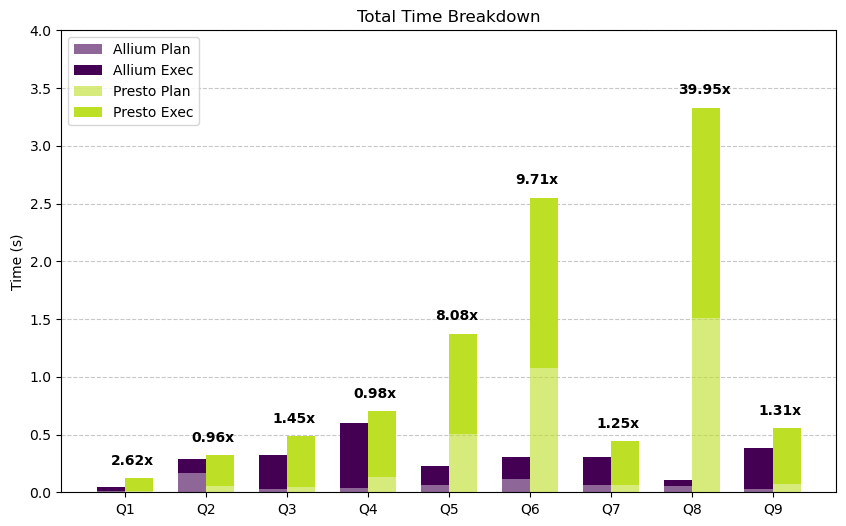

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

# If your data is in a file named 'data.json'
with open('data/fdbs_performance/query_performance.json', 'r') as f:
    raw_data = json.load(f)

# Convert to DataFrame
df = pd.json_normalize(raw_data)

# Clean up column names for easier access
# This changes 'allium-sativum.total' to 'allium_total'
df.columns = [c.replace('alliumSativum.', 'allium_').replace('presto.', 'presto_').replace('.', '_') for c in df.columns]

df['speedup'] = df['presto_total'] / df['allium_total']

df['allium_total'] = df['allium_total'] / 1_000 # to seconds
df['presto_total'] = df['presto_total'] / 1_000 # to seconds
df['allium_plan_total'] = df['allium_plan_total'] / 1_000 # to seconds
df['allium_execute'] = df['allium_execute'] / 1_000 # to seconds
df['presto_plan'] = df['presto_plan'] / 1_000 # to seconds
df['presto_execute'] = df['presto_execute'] / 1_000 # to seconds

# Visualization
colors = plt.cm.viridis(np.linspace(0, 0.9, 4))

x = np.arange(len(df['query_short']))
width = 0.35


plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df['allium_plan_total'], width, label='Allium Plan', color=colors[0], alpha=0.6, zorder=2)
plt.bar(x - width/2, df['allium_execute'], width, bottom=df['allium_plan_total'], label='Allium Exec', color=colors[0], zorder=2)
plt.bar(x + width/2, df['presto_plan'], width, label='Presto Plan', color=colors[3], alpha=0.6, zorder=2)
plt.bar(x + width/2, df['presto_execute'], width, bottom=df['presto_plan'], label='Presto Exec', color=colors[3], zorder=2)

for i, v in enumerate(df['speedup']):
    position_presto = df['presto_execute'][i] + df['presto_plan'][i]
    position_alliumsativum = df['allium_execute'][i] + df['allium_plan_total'][i]
    plt.text(i - (width / 2), max(position_presto, position_alliumsativum) + 0.15, f"{v:.2f}x", va='center', fontweight='bold', zorder=2)

plt.ylim(0, 4)
plt.ylabel('Time (s)')
plt.title('Total Time Breakdown')
plt.xticks(x, df['query_short'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.savefig('images/fdbs_performance/performance_breakdown.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.close()


# Save data